# Financial Risk Intelligence & Bankruptcy Prediction Platform

**Objective:** Identify companies at high risk of bankruptcy using financial statement ratios and machine learning, and translate model outputs into business-ready risk insights.

**Dataset:** ~6,800 SME companies, 95 financial ratio features (Profitability, Liquidity, Leverage, Efficiency, Cash Flow, Growth).

**Tech Stack:** Python, Pandas, NumPy, Scikit-learn, SHAP, Seaborn/Matplotlib.

## 1. Import Libraries

Core libraries for data handling, visualization, and modeling used throughout this notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

## 2. Load Dataset

Load the raw dataset and take a first look at its structure.

In [2]:
# Load dataset
df = pd.read_csv("data.csv")

df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


## 3. Data Validation

Before modeling, the dataset is validated for shape, data types, missing values, duplicates, unique values, descriptive statistics, target balance, outliers, and correlation structure.

In [3]:
df.shape

(6819, 96)

In [4]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [5]:
df.dtypes

Bankrupt?                                                     int64
 ROA(C) before interest and depreciation before interest    float64
 ROA(A) before interest and % after tax                     float64
 ROA(B) before interest and depreciation after tax          float64
 Operating Gross Margin                                     float64
                                                             ...   
 Liability to Equity                                        float64
 Degree of Financial Leverage (DFL)                         float64
 Interest Coverage Ratio (Interest expense to EBIT)         float64
 Net Income Flag                                              int64
 Equity to Liability                                        float64
Length: 96, dtype: object

In [6]:
# Check missing values
missing_count = df.isnull().sum()

missing_percent = (
    df.isnull().sum() / len(df)
)*100

missing_table = pd.DataFrame({
    "Missing Count":missing_count,
    "Missing %":missing_percent
})

missing_table.sort_values(
    by="Missing %",
    ascending=False
)

,Missing Count,Missing %
Bankrupt?,0,0.0
ROA(C) before interest and depreciation before interest,0,0.0
Total expense/Assets,0,0.0
Total income/Total expense,0,0.0
Retained Earnings to Total Assets,0,0.0
...,...,...
Total Asset Growth Rate,0,0.0
Continuous Net Profit Growth Rate,0,0.0
Regular Net Profit Growth Rate,0,0.0
After-tax Net Profit Growth Rate,0,0.0


In [7]:
# Check duplicate records
df.duplicated().sum()

np.int64(0)

In [8]:
# Check unique values per column
df.nunique()

Bankrupt?                                                      2
 ROA(C) before interest and depreciation before interest    3333
 ROA(A) before interest and % after tax                     3151
 ROA(B) before interest and depreciation after tax          3160
 Operating Gross Margin                                     3781
                                                            ... 
 Liability to Equity                                        6819
 Degree of Financial Leverage (DFL)                         6240
 Interest Coverage Ratio (Interest expense to EBIT)         6240
 Net Income Flag                                               1
 Equity to Liability                                        6819
Length: 96, dtype: int64

In [9]:
# Descriptive statistics
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


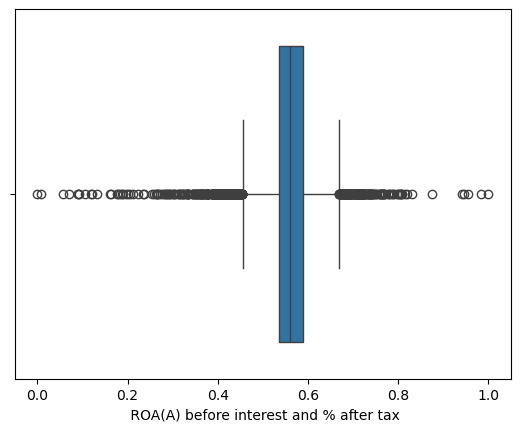

In [10]:
# Outlier assessment
sns.boxplot(x=df[" ROA(A) before interest and % after tax"])
plt.show()

In [11]:
# Target variable validation
df["Bankrupt?"].value_counts()

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

In [12]:
df["Bankrupt?"].value_counts(normalize=True)*100

Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64

In [13]:
# Distribution analysis (skewness)
df.skew().sort_values(
    ascending=False
)

Fixed Assets to Assets                  82.577237
Current Ratio                           82.577237
Total income/Total expense              82.332424
Net Value Growth Rate                   80.291844
Contingent liabilities/Net worth        79.670620
                                          ...    
Pre-tax net Interest Rate              -52.482867
After-tax net Interest Rate            -52.995744
Continuous interest rate (after tax)   -53.200121
Operating Profit Rate                  -70.237164
Operating Profit Growth Rate           -71.688950
Length: 96, dtype: float64

In [14]:
# Correlation analysis
corr_matrix = df.corr()

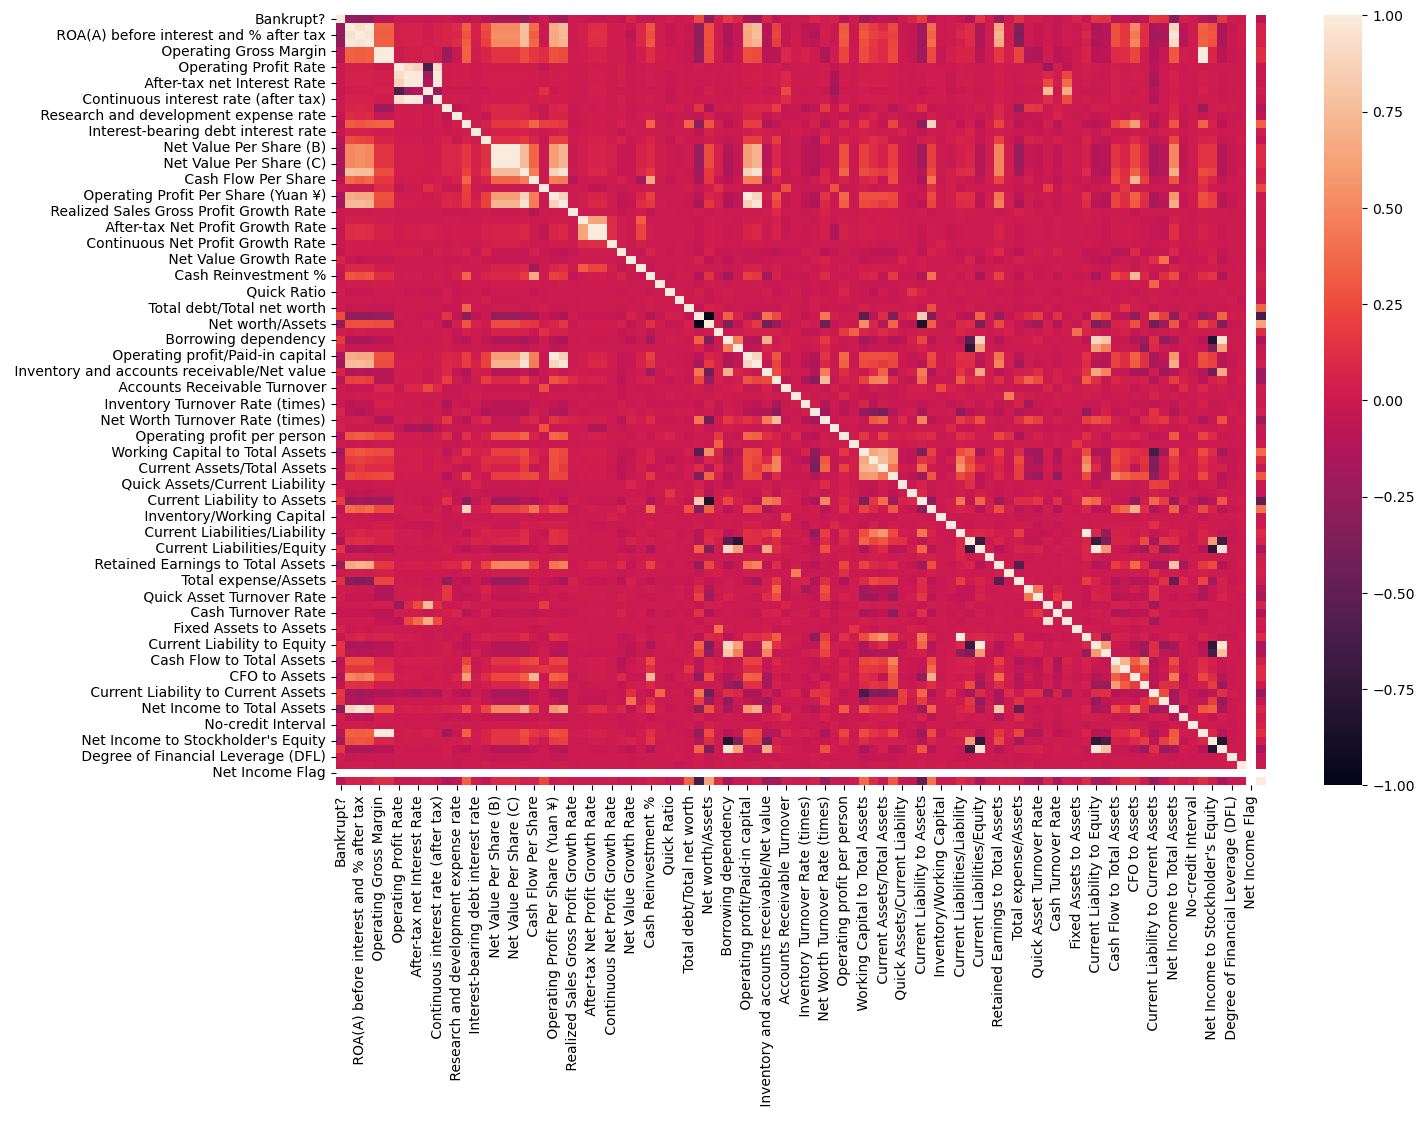

In [15]:
plt.figure(figsize=(15,10))
sns.heatmap(corr_matrix)
plt.show()

In [16]:
corr_matrix.abs()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
Bankrupt?,1.000000,0.260807,0.282941,0.273051,0.100043,0.099445,0.000230,0.008517,0.008857,0.016593,...,0.315457,0.035104,0.005547,0.100044,0.180987,0.166812,0.010508,0.005509,NaN,0.083048
ROA(C) before interest and depreciation before interest,0.260807,1.000000,0.940124,0.986849,0.334719,0.332755,0.035725,0.053419,0.049222,0.020501,...,0.887670,0.071725,0.008135,0.334721,0.274287,0.143629,0.016575,0.010573,NaN,0.052416
ROA(A) before interest and % after tax,0.282941,0.940124,1.000000,0.955741,0.326969,0.324956,0.032053,0.053518,0.049474,0.029649,...,0.961552,0.098900,0.011463,0.326971,0.291744,0.141039,0.011515,0.013372,NaN,0.057887
ROA(B) before interest and depreciation after tax,0.273051,0.986849,0.955741,1.000000,0.333749,0.331755,0.035212,0.053726,0.049952,0.022366,...,0.912040,0.089088,0.007523,0.333750,0.280617,0.142838,0.014663,0.011473,NaN,0.056430
Operating Gross Margin,0.100043,0.334719,0.326969,0.333749,1.000000,0.999518,0.005745,0.032493,0.027175,0.051438,...,0.300143,0.022672,0.004205,1.000000,0.075304,0.085434,0.011806,0.001167,NaN,0.120029
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Liability to Equity,0.166812,0.143629,0.141039,0.142838,0.085434,0.085407,0.001541,0.004043,0.004390,0.011899,...,0.159697,0.021982,0.003724,0.085434,0.791836,1.000000,0.002119,0.001487,NaN,0.159654
Degree of Financial Leverage (DFL),0.010508,0.016575,0.011515,0.014663,0.011806,0.011268,0.000935,0.000855,0.000927,0.000556,...,0.010463,0.001881,0.008812,0.011806,0.000093,0.002119,1.000000,0.016513,NaN,0.016739
Interest Coverage Ratio (Interest expense to EBIT),0.005509,0.010573,0.013372,0.011473,0.001167,0.001158,0.000393,0.000984,0.000957,0.001024,...,0.012746,0.000239,0.001027,0.001169,0.005147,0.001487,0.016513,1.000000,NaN,0.008339
Net Income Flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# Identify constant (zero-variance) features
for col in df.columns:
    if df[col].nunique() == 1:
        print(col)

 Net Income Flag


In [18]:
# Locate the Net Income Flag column
for col in df.columns:
    if 'Net' in col:
        print(col)

 Net Value Per Share (B)
 Net Value Per Share (A)
 Net Value Per Share (C)
 Per Share Net profit before tax (Yuan ¥)
 After-tax Net Profit Growth Rate
 Regular Net Profit Growth Rate
 Continuous Net Profit Growth Rate
 Net Value Growth Rate
 Net worth/Assets
 Contingent liabilities/Net worth
 Net profit before tax/Paid-in capital
 Inventory and accounts receivable/Net value
 Net Worth Turnover Rate (times)
 Net Income to Total Assets
 Net Income to Stockholder's Equity
 Net Income Flag


In [19]:
'Net Income Flag' in df.columns

False

In [20]:
# Identify highly correlated feature pairs (threshold > 0.90)
corr_matrix = df.corr().abs()

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.90:
            high_corr_pairs.append([
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ])

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=['Feature 1', 'Feature 2', 'Correlation']
)

high_corr_df.sort_values(
    by='Correlation',
    ascending=False
)

,Feature 1,Feature 2,Correlation
19,Current Liability to Liability,Current Liabilities/Liability,1.000000
20,Current Liability to Equity,Current Liabilities/Equity,1.000000
14,Net worth/Assets,Debt ratio %,1.000000
23,Gross Profit to Sales,Operating Gross Margin,1.000000
11,Net Value Per Share (C),Net Value Per Share (A),0.999837
3,Realized Sales Gross Margin,Operating Gross Margin,0.999518
24,Gross Profit to Sales,Realized Sales Gross Margin,0.999518
9,Net Value Per Share (A),Net Value Per Share (B),0.999342
10,Net Value Per Share (C),Net Value Per Share (B),0.999179
15,Operating profit/Paid-in capital,Operating Profit Per Share (Yuan ¥),0.998696


## 4. Exploratory Data Analysis

Financial ratios are examined by business category (Profitability, Liquidity, Leverage, Efficiency, Cash Flow, Growth) to understand what distinguishes bankrupt companies from healthy ones.

In [21]:
# Bankruptcy class distribution
df['Bankrupt?'].value_counts()

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

In [22]:
df['Bankrupt?'].value_counts(normalize=True)*100

Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64

In [23]:
# EDA 2: Profitability Analysis -- Are bankrupt companies less profitable than healthy companies?
profitability_cols = [
    ' ROA(A) before interest and % after tax',
    ' ROA(B) before interest and depreciation after tax',
    ' ROA(C) before interest and depreciation before interest'
]

df.groupby('Bankrupt?')[profitability_cols].mean()
# ROA IS DECLINING MEANS COMPANY GO BANKCRUPT SOON 

,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,ROA(C) before interest and depreciation before interest
Bankrupt?,,,
0,0.562015,0.556659,0.508069
1,0.456947,0.461483,0.418503


In [24]:
#Next Step: Liquidity Analysis
liquidity_cols = [
    ' Current Ratio',
    ' Quick Ratio'
]

df.groupby('Bankrupt?')[liquidity_cols].mean()

# output is somewhere to big because one high value ca pull up whole mean i.e we have to use median 

,Current Ratio,Quick Ratio
Bankrupt?,,
0,416729.822913,7.257160e+06
1,0.007238,4.195455e+07


In [25]:
df.groupby('Bankrupt?')[[' Current Ratio',' Quick Ratio']].median()
# insight --Both liquidity ratios are lower for bankrupt companies.

,Current Ratio,Quick Ratio
Bankrupt?,,
0,0.010771,0.007579
1,0.006029,0.002751


In [26]:
# Next EDA Step: Leverage Analysis -- Are bankrupt companies carrying higher debt burdens?

leverage_cols = [
    ' Debt ratio %',
    ' Net worth/Assets',
    ' Borrowing dependency'
]

df.groupby('Bankrupt?')[leverage_cols].mean()
# Companies with excessive leverage and weaker equity positions are more vulnerable to financial distress.

,Debt ratio %,Net worth/Assets,Borrowing dependency
Bankrupt?,,,
0,0.110714,0.889286,0.374129
1,0.187047,0.812953,0.390400


In [27]:
# Efficiency Analysis -- Are bankrupt firms using their assets less efficiently?
efficiency_cols = [
    ' Total Asset Turnover',
    ' Net Worth Turnover Rate (times)'
]

df.groupby('Bankrupt?')[efficiency_cols].mean()

,Total Asset Turnover,Net Worth Turnover Rate (times)
Bankrupt?,,
0,0.142860,0.038454
1,0.103987,0.042831


In [28]:
# Cash Flow Analysis
cashflow_cols = [
    ' Cash Flow to Total Assets',
    ' Cash Flow to Liability',
    ' CFO to Assets'
]

df.groupby('Bankrupt?')[cashflow_cols].mean()

,Cash Flow to Total Assets,Cash Flow to Liability,CFO to Assets
Bankrupt?,,,
0,0.650340,0.462085,0.594649
1,0.631452,0.454778,0.556412


In [29]:
# Growth Analysis
growth_cols = [
    ' Total Asset Growth Rate',
    ' Net Value Growth Rate',
    ' Continuous Net Profit Growth Rate'
]

df.groupby('Bankrupt?')[growth_cols].mean()

,Total Asset Growth Rate,Net Value Growth Rate,Continuous Net Profit Growth Rate
Bankrupt?,,,
0,5.531603e+09,2.045765e+05,0.217656
1,4.803017e+09,4.240909e+07,0.217121


In [30]:
# Financial Distress Pattern Discovery -- Top 15 features most correlated with bankruptcy
corr_with_target = (
    df.corr()['Bankrupt?']
      .abs()
      .sort_values(ascending=False)
)

corr_with_target.head(15)

Bankrupt?                                                   1.000000
 Net Income to Total Assets                                 0.315457
 ROA(A) before interest and % after tax                     0.282941
 ROA(B) before interest and depreciation after tax          0.273051
 ROA(C) before interest and depreciation before interest    0.260807
 Net worth/Assets                                           0.250161
 Debt ratio %                                               0.250161
 Persistent EPS in the Last Four Seasons                    0.219560
 Retained Earnings to Total Assets                          0.217779
 Net profit before tax/Paid-in capital                      0.207857
 Per Share Net profit before tax (Yuan ¥)                   0.201395
 Current Liability to Assets                                0.194494
 Working Capital to Total Assets                            0.193083
 Net Income to Stockholder's Equity                         0.180987
 Borrowing dependency             

**Key EDA Insights**

- The top financial indicators associated with bankruptcy are dominated by **profitability** measures (ROA, Net Income to Total Assets, Persistent EPS, Retained Earnings to Total Assets) — profitability is the strongest characteristic separating bankrupt and healthy companies.
- **Net worth/Assets** and **Debt ratio %** (leverage) are also strong indicators.
- Overall: bankrupt companies consistently show lower profitability, higher leverage, weaker liquidity, reduced cash flow generation, and lower operational efficiency.

## 5. Data Preparation

The dataset is split into train/test sets (stratified, to preserve class balance), the constant `Net Income Flag` feature is removed, and class imbalance is addressed. Feature scaling is prepared for Logistic Regression, which is scale-sensitive.

In [31]:
# Train-Test Split
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [33]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain Bankruptcy %")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest Bankruptcy %")
print(y_test.value_counts(normalize=True) * 100)

X_train shape: (5455, 95)
X_test shape: (1364, 95)

Train Bankruptcy %
Bankrupt?
0    96.773602
1     3.226398
Name: proportion, dtype: float64

Test Bankruptcy %
Bankrupt?
0    96.774194
1     3.225806
Name: proportion, dtype: float64


In [34]:
# Confirm the constant feature before removing it
df[' Net Income Flag'].value_counts()

 Net Income Flag
1    6819
Name: count, dtype: int64

In [35]:
# Remove constant feature (Net Income Flag) -- no predictive value
df = df.drop(' Net Income Flag', axis=1)

In [36]:
# Re-create X and y after dropping the constant feature
X = df.drop('Bankrupt?', axis=1)
y = df['Bankrupt?']

In [37]:
# Class Imbalance Handling
#
# The dataset contains only 3.23% bankrupt companies, indicating severe class imbalance.
# To ensure the model appropriately learns patterns associated with bankrupt firms,
# class weights will be used during model training.
#
# Models:
# - Logistic Regression (class_weight='balanced')
# - Random Forest (class_weight='balanced')

In [38]:
class_weight='balanced'

In [39]:
# Feature Scaling
#
# Logistic Regression requires feature scaling because it is sensitive to feature magnitude.
# StandardScaler will be applied using training data only (fit on train, transform on test).
#
# Random Forest does not require scaling because tree-based algorithms are scale-invariant.

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [41]:
X_train_scaled.shape
X_test_scaled.shape

(1364, 95)

## 6. Feature Engineering

Highly correlated features (correlation > 0.90) are removed using **training data only** to prevent data leakage. A quick Random Forest is then trained to rank feature importance, and the model is narrowed down to the top 30 predictive features.

In [42]:
# Multicollinearity Treatment (train data only, to avoid leakage)
corr_matrix = X_train.corr().abs()

In [43]:
import numpy as np

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.90)
]

print("Features to consider removing:", len(high_corr))
print(high_corr)

Features to consider removing: 21
[' ROA(A) before interest and % after tax', ' ROA(B) before interest and depreciation after tax', ' Realized Sales Gross Margin', ' Pre-tax net Interest Rate', ' After-tax net Interest Rate', ' Continuous interest rate (after tax)', ' Net Value Per Share (A)', ' Net Value Per Share (C)', ' Per Share Net profit before tax (Yuan ¥)', ' Regular Net Profit Growth Rate', ' Total Asset Return Growth Rate Ratio', ' Net worth/Assets', ' Operating profit/Paid-in capital', ' Net profit before tax/Paid-in capital', ' Working capitcal Turnover Rate', ' Cash Flow to Sales', ' Current Liability to Liability', ' Current Liability to Equity', ' Net Income to Total Assets', ' Gross Profit to Sales', ' Liability to Equity']


In [44]:
features_to_drop = [
' ROA(A) before interest and % after tax',
' ROA(B) before interest and depreciation after tax',
' Realized Sales Gross Margin',
' Pre-tax net Interest Rate',
' After-tax net Interest Rate',
' Continuous interest rate (after tax)',
' Net Value Per Share (A)',
' Net Value Per Share (C)',
' Per Share Net profit before tax (Yuan ¥)',
' Regular Net Profit Growth Rate',
' Total Asset Return Growth Rate Ratio',
' Net worth/Assets',
' Operating profit/Paid-in capital',
' Net profit before tax/Paid-in capital',
' Working capitcal Turnover Rate',
' Cash Flow to Sales',
' Current Liability to Liability',
' Current Liability to Equity',
' Net Income to Total Assets',
' Gross Profit to Sales',
' Liability to Equity'
]

In [45]:
95 - len(features_to_drop)

74

In [46]:
# Verify which features are driving the correlation for each candidate
corr_matrix = X_train.corr().abs()

for col in features_to_drop:
    corr_features = corr_matrix.index[
        (corr_matrix[col] > 0.90) & (corr_matrix.index != col)
    ].tolist()

    print(f"\n{col}")
    print(corr_features)


 ROA(A) before interest and % after tax
[' ROA(C) before interest and depreciation before interest', ' ROA(B) before interest and depreciation after tax', ' Net Income to Total Assets']

 ROA(B) before interest and depreciation after tax
[' ROA(C) before interest and depreciation before interest', ' ROA(A) before interest and % after tax', ' Net Income to Total Assets']

 Realized Sales Gross Margin
[' Operating Gross Margin', ' Gross Profit to Sales']

 Pre-tax net Interest Rate
[' Operating Profit Rate', ' After-tax net Interest Rate', ' Continuous interest rate (after tax)']

 After-tax net Interest Rate
[' Operating Profit Rate', ' Pre-tax net Interest Rate', ' Continuous interest rate (after tax)']

 Continuous interest rate (after tax)
[' Operating Profit Rate', ' Pre-tax net Interest Rate', ' After-tax net Interest Rate']

 Net Value Per Share (A)
[' Net Value Per Share (B)', ' Net Value Per Share (C)']

 Net Value Per Share (C)
[' Net Value Per Share (B)', ' Net Value Per Shar

In [47]:
# Final list of correlated features to drop
features_to_drop_final = [
' ROA(A) before interest and % after tax',
' ROA(B) before interest and depreciation after tax',
' Realized Sales Gross Margin',
' Gross Profit to Sales',
' Pre-tax net Interest Rate',
' After-tax net Interest Rate',
' Continuous interest rate (after tax)',
' Net Value Per Share (A)',
' Net Value Per Share (C)',
' Per Share Net profit before tax (Yuan ¥)',
' Regular Net Profit Growth Rate',
' Total Asset Return Growth Rate Ratio',
' Net worth/Assets',
' Operating profit/Paid-in capital',
' Net profit before tax/Paid-in capital',
' Current Liability to Liability',
' Current Liability to Equity'
]

In [48]:
X_train_lr = X_train.drop(columns=features_to_drop_final)
X_test_lr = X_test.drop(columns=features_to_drop_final)

In [49]:
print(X_train_lr.shape)
print(X_test_lr.shape)

(5455, 78)
(1364, 78)


In [50]:
# Feature Selection: train a quick Random Forest to rank feature importance
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train_lr, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [51]:
feature_importance = pd.DataFrame({
    'Feature': X_train_lr.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
25,Debt ratio %,0.063317
10,Persistent EPS in the Last Four Seasons,0.058869
54,Total income/Total expense,0.056215
27,Borrowing dependency,0.051216
24,Total debt/Total net worth,0.047770
69,Net Income to Total Assets,0.043554
53,Retained Earnings to Total Assets,0.042735
74,Degree of Financial Leverage (DFL),0.037999
0,ROA(C) before interest and depreciation befor...,0.033554
77,Equity to Liability,0.030655


In [52]:
# Select the top 30 most important features
top_30_features = feature_importance.head(30)['Feature'].tolist()

print(top_30_features)
print(len(top_30_features))

[' Debt ratio %', ' Persistent EPS in the Last Four Seasons', ' Total income/Total expense', ' Borrowing dependency', ' Total debt/Total net worth', ' Net Income to Total Assets', ' Retained Earnings to Total Assets', ' Degree of Financial Leverage (DFL)', ' ROA(C) before interest and depreciation before interest', ' Equity to Liability', ' Non-industry income and expenditure/revenue', " Net Income to Stockholder's Equity", ' Liability to Equity', ' Quick Ratio', ' Interest Coverage Ratio (Interest expense to EBIT)', ' Net Value Per Share (B)', ' Operating profit per person', ' Interest Expense Ratio', ' Current Liability to Current Assets', ' Net Value Growth Rate', ' Allocation rate per person', ' Current Ratio', ' Tax rate (A)', ' Inventory/Working Capital', ' Current Liability to Assets', ' Cash Turnover Rate', ' Current Liabilities/Equity', ' Operating Profit Rate', ' Quick Assets/Current Liability', ' Accounts Receivable Turnover']
30


In [53]:
# Create the final modeling dataset using the top 30 features
X_train_final = X_train_lr[top_30_features]
X_test_final = X_test_lr[top_30_features]

In [54]:
X_train_final.shape
X_test_final.shape

(1364, 30)

In [55]:
# Final Scaling (for Logistic Regression on the top-30 feature set)
scaler_final = StandardScaler()

X_train_final_scaled = scaler_final.fit_transform(X_train_final)

X_test_final_scaled = scaler_final.transform(X_test_final)

In [56]:
X_train_final_scaled.shape
X_test_final_scaled.shape

(1364, 30)

## 7. Model Development

Two models are trained on the top-30 feature set: **Logistic Regression** (baseline, scaled features) and **Random Forest** (unscaled features). Both use `class_weight='balanced'` to handle the class imbalance.

**7.1 Logistic Regression (Baseline Model)**

In [57]:
# Train Logistic Regression model
lr_model = LogisticRegression(
    class_weight='balanced',  # Because dataset is highly imbalanced.
    random_state=42,
    max_iter=1000  # Allows convergence -- financial datasets often need more iterations.
)

lr_model.fit(
    X_train_final_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [58]:
# Generate predictions
y_pred_lr = lr_model.predict(
    X_test_final_scaled
)

y_prob_lr = lr_model.predict_proba(
    X_test_final_scaled
)[:,1]

In [59]:
# Evaluate Logistic Regression
print(confusion_matrix(
    y_test,
    y_pred_lr
))

print(classification_report(
    y_test,
    y_pred_lr
))

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_lr
    )
)

[[1162  158]
 [   9   35]]
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1320
           1       0.18      0.80      0.30        44

    accuracy                           0.88      1364
   macro avg       0.59      0.84      0.61      1364
weighted avg       0.97      0.88      0.91      1364

ROC-AUC: 0.8879648760330578


**7.2 Random Forest**

In [60]:
# Train Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_final,
    y_train
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
y_pred_rf = rf_model.predict(X_test_final)

y_prob_rf = rf_model.predict_proba(X_test_final)[:, 1]

In [62]:
# Evaluate Random Forest
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nROC-AUC Score")
print(roc_auc_score(y_test, y_prob_rf))

Confusion Matrix
[[1316    4]
 [  31   13]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1320
           1       0.76      0.30      0.43        44

    accuracy                           0.97      1364
   macro avg       0.87      0.65      0.71      1364
weighted avg       0.97      0.97      0.97      1364


ROC-AUC Score
0.9385416666666666


## 8. Model Evaluation

Random Forest outperforms Logistic Regression on accuracy, precision, and ROC-AUC, while Logistic Regression achieves higher recall on the minority (bankrupt) class. Random Forest is selected as the final model.

**Model Comparison**

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 88% | 97% |
| Precision | 18% | 76% |
| Recall | 80% | 30% |
| F1 Score | 0.30 | 0.43 |
| ROC-AUC | 0.888 | 0.939 |

In [63]:
# Threshold Optimization -- by default, probability >= 0.5 is classified as bankrupt.
# Here we test how Precision/Recall/F1 change at different probability thresholds.
threshold_results = []

for threshold in [0.1, 0.2, 0.3, 0.4, 0.5]:

    preds = (y_prob_rf >= threshold).astype(int)

    threshold_results.append({
        'Threshold': threshold,
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.1,0.324074,0.795455,0.460526
1,0.2,0.461538,0.681818,0.550459
2,0.3,0.431818,0.431818,0.431818
3,0.4,0.548387,0.386364,0.453333
4,0.5,0.764706,0.295455,0.426230


## 9. Explainable AI

The final Random Forest is retrained for explainability analysis. Feature importance and **SHAP (SHapley Additive exPlanations)** are used to understand which financial variables drive individual bankruptcy predictions.

In [64]:
# Retrain the final Random Forest model for explainability
rf_final = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_final.fit(X_train_final, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
# Feature importance from the final Random Forest model
feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": rf_final.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,Persistent EPS in the Last Four Seasons,0.099880
3,Borrowing dependency,0.080972
6,Retained Earnings to Total Assets,0.066356
9,Equity to Liability,0.063130
0,Debt ratio %,0.060948
5,Net Income to Total Assets,0.054575
2,Total income/Total expense,0.054228
4,Total debt/Total net worth,0.045118
11,Net Income to Stockholder's Equity,0.032978
12,Liability to Equity,0.032882


In [66]:
# Install SHAP for model explainability
!pip install shap

In [67]:
import shap

In [68]:
# Build a SHAP explainer for the Random Forest model
explainer = shap.TreeExplainer(rf_final)

In [69]:
# Explain a single company's prediction
company = X_train_final.iloc[[0]]

In [70]:
shap_values = explainer(company)

In [71]:
print("Bankruptcy Probability:", rf_final.predict_proba(company)[0][1])

Bankruptcy Probability: 0.0


In [90]:
shap.plots.waterfall(shap_values[0])

ValueError: The waterfall plot can currently only plot a single explanation, but a matrix of explanations (shape (30, 2)) was passed! Perhaps try `shap.plots.waterfall(shap_values[0])` or for multi-output models, try `shap.plots.waterfall(shap_values[0, 0])`.

In [ ]:
print(shap_values.shape)

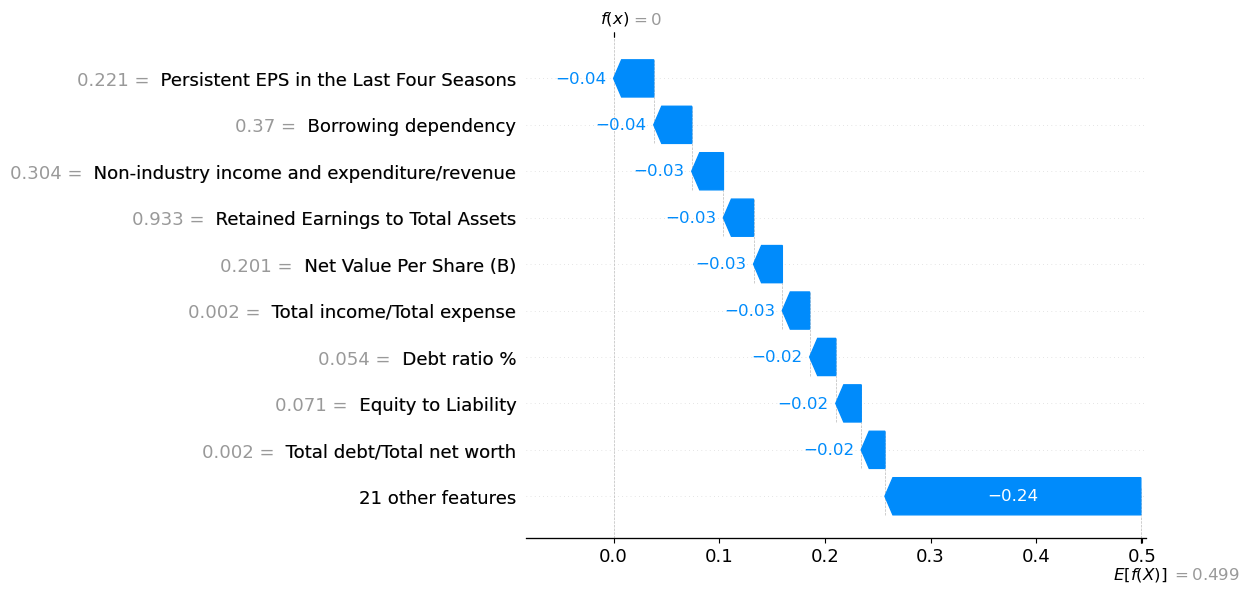

In [73]:
# Waterfall plot for the bankruptcy (positive) class
shap.plots.waterfall(shap_values[0, :, 1])

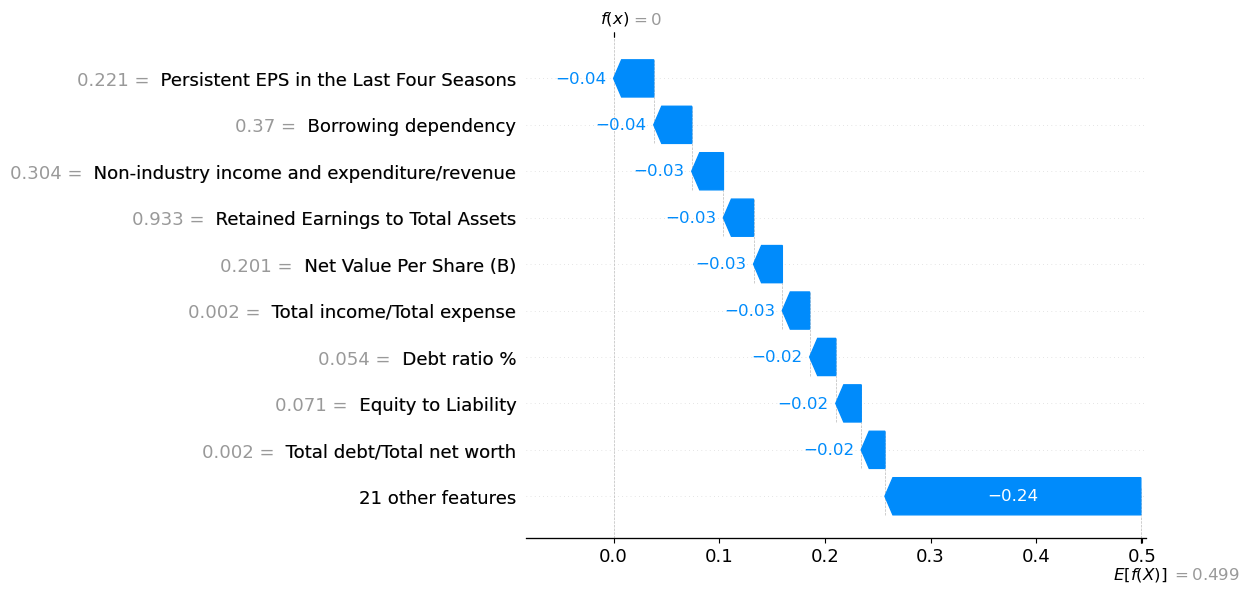

In [74]:
shap.plots.waterfall(shap_values[..., 1][0])

In [75]:
# Identify the company with the highest predicted bankruptcy probability
probs = rf_final.predict_proba(X_train_final)[:, 1]

idx = probs.argmax()

print(idx)
print(probs[idx])

3801
0.92


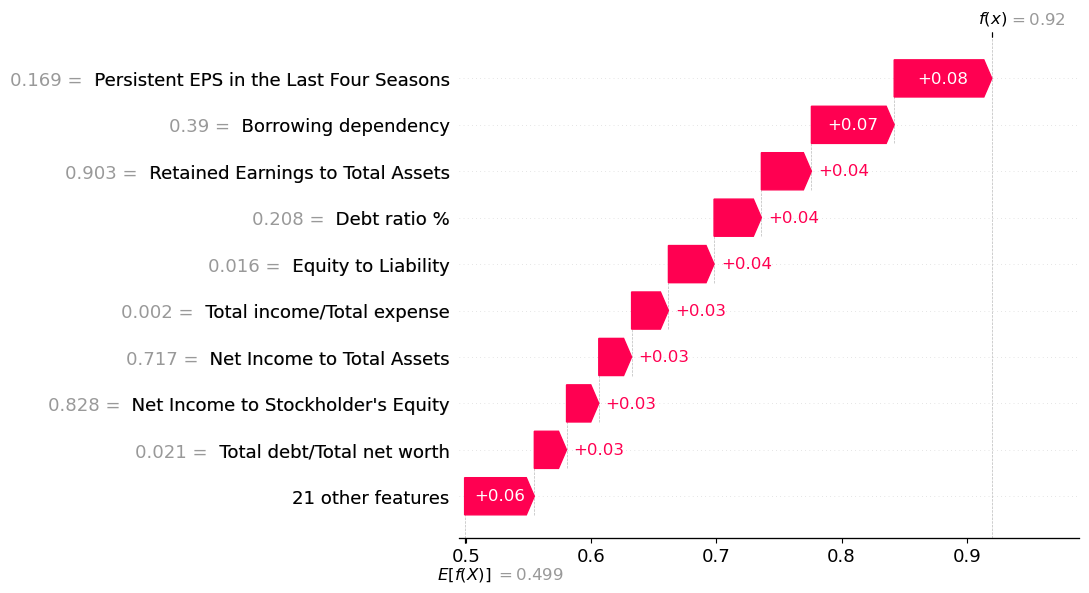

In [76]:
# SHAP explanation for the highest-risk company
company = X_train_final.iloc[[idx]]

shap_values = explainer(company)

shap.plots.waterfall(shap_values[0, :, 1])

In [77]:
print(shap_values.shape)

(1, 30, 2)


## 10. Financial Intelligence Layer

Model outputs are converted into business-friendly metrics: a **Financial Health Score (0–100)**, a **Risk Category**, and a rule-based **Business Recommendation** for each company.

In [78]:
# Financial Health Score (0-100)
bankruptcy_probability = rf_final.predict_proba(X_test_final)[:, 1]

financial_health_score = (1 - bankruptcy_probability) * 100

In [79]:
results = X_test_final.copy()

results["Bankruptcy Probability"] = bankruptcy_probability
results["Financial Health Score"] = financial_health_score.round(2)

results.head()

,Debt ratio %,Persistent EPS in the Last Four Seasons,Total income/Total expense,Borrowing dependency,Total debt/Total net worth,Net Income to Total Assets,Retained Earnings to Total Assets,Degree of Financial Leverage (DFL),ROA(C) before interest and depreciation before interest,Equity to Liability,...,Tax rate (A),Inventory/Working Capital,Current Liability to Assets,Cash Turnover Rate,Current Liabilities/Equity,Operating Profit Rate,Quick Assets/Current Liability,Accounts Receivable Turnover,Bankruptcy Probability,Financial Health Score
1244,0.157995,0.221424,0.002277,0.377514,0.010452,0.805667,0.934622,0.027273,0.503242,0.022839,...,0.305294,0.277450,0.102555,3.600000e+09,0.331976,0.999043,0.006166,0.000745,0.00,100.0
6303,0.106721,0.220384,0.002322,0.374069,0.005165,0.803448,0.944185,0.027098,0.485984,0.035415,...,0.404899,0.276449,0.108178,9.800000e+08,0.330648,0.999002,0.005512,0.000692,0.01,99.0
4712,0.108202,0.256784,0.002717,0.372164,0.005278,0.839238,0.945701,0.026816,0.554380,0.034892,...,0.068327,0.277169,0.077370,1.174779e-04,0.329401,0.999043,0.006959,0.000637,0.00,100.0
3273,0.062430,0.279380,0.002565,0.370533,0.002454,0.879037,0.962526,0.026805,0.663920,0.061798,...,0.147181,0.277020,0.047131,3.016747e-04,0.327758,0.999314,0.022398,0.001672,0.00,100.0
6430,0.016507,0.208188,0.002190,0.369637,0.000543,0.782600,0.928248,0.026709,0.450641,0.207130,...,0.000000,0.276980,0.016797,1.928585e-04,0.326646,0.998738,0.038864,0.001088,0.00,100.0


In [80]:
# Risk Categorization
def risk_category(prob):
    if prob < 0.20:
        return "Low"
    elif prob < 0.40:
        return "Medium"
    elif prob < 0.60:
        return "High"
    else:
        return "Critical"

results["Risk Category"] = results["Bankruptcy Probability"].apply(risk_category)

In [81]:
results["Risk Category"].value_counts()

Risk Category
Low         1299
Medium        34
High          26
Critical       5
Name: count, dtype: int64

**Business Recommendation Engine**

Rule-based recommendations are generated for each company based on key risk-driving financial ratios identified through feature importance and SHAP.

In [82]:
# Standardize column names before defining rule thresholds
X_train_final.columns = X_train_final.columns.str.strip()
X_test_final.columns = X_test_final.columns.str.strip()

In [83]:
important_features = [
    "Debt ratio %",
    "Borrowing dependency",
    "Persistent EPS in the Last Four Seasons",
    "Net Income to Total Assets",
    "Retained Earnings to Total Assets",
    "Total debt/Total net worth"
]

X_train_final[important_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Debt ratio %,5455.0,1.132499e-01,5.424757e-02,0.000000,0.072860,0.111407,0.148940,1.000000e+00
Borrowing dependency,5455.0,3.746667e-01,1.431347e-02,0.187124,0.370154,0.372628,0.376268,9.548194e-01
Persistent EPS in the Last Four Seasons,5455.0,2.283208e-01,3.189100e-02,0.078567,0.214617,0.224260,0.237875,1.000000e+00
Net Income to Total Assets,5455.0,8.074199e-01,3.995369e-02,0.000000,0.796642,0.810357,0.826091,1.000000e+00
Retained Earnings to Total Assets,5455.0,9.345257e-01,2.613299e-02,0.000000,0.930842,0.937552,0.944605,9.988580e-01
Total debt/Total net worth,5455.0,2.294225e+06,9.706757e+07,0.000000,0.003008,0.005542,0.009283,5.930000e+09


In [84]:
# Define rule-based risk recommendations using the important financial ratios above
def generate_recommendation(row):
    recommendations = []

    if row["Debt ratio %"] > 0.148940:
        recommendations.append("Reduce debt through restructuring or controlled borrowing.")

    if row["Borrowing dependency"] > 0.376268:
        recommendations.append("Reduce dependence on external financing.")

    if row["Persistent EPS in the Last Four Seasons"] < 0.214617:
        recommendations.append("Improve earnings consistency through operational improvements.")

    if row["Net Income to Total Assets"] < 0.796642:
        recommendations.append("Improve profitability and optimize asset utilization.")

    if row["Retained Earnings to Total Assets"] < 0.930842:
        recommendations.append("Strengthen retained earnings by improving profitability and limiting unnecessary dividend payouts.")

    if row["Total debt/Total net worth"] > 0.009283:
        recommendations.append("Reduce leverage and strengthen the company's equity position.")

    if len(recommendations) == 0:
        return "Financial position is healthy. Continue regular monitoring."

    return " | ".join(recommendations)

In [85]:
# Standardize results column names before applying the recommendation engine
results.columns = results.columns.str.strip()

In [86]:
# Apply the recommendation engine to every company
results["Business Recommendation"] = results.apply(generate_recommendation, axis=1)

## 11. Final Dataset Export

The final risk outputs (Bankruptcy Probability, Financial Health Score, Risk Category, Business Recommendation) are compiled into a dashboard-ready table and exported to CSV for use in Power BI.

In [87]:
# Dashboard-Ready Output Table
dashboard_data = results[[
    "Bankruptcy Probability",
    "Financial Health Score",
    "Risk Category",
    "Business Recommendation"
]].copy()

dashboard_data.head()

,Bankruptcy Probability,Financial Health Score,Risk Category,Business Recommendation
1244,0.00,100.0,Low,Reduce debt through restructuring or controlle...
6303,0.01,99.0,Low,Financial position is healthy. Continue regula...
4712,0.00,100.0,Low,Financial position is healthy. Continue regula...
3273,0.00,100.0,Low,Financial position is healthy. Continue regula...
6430,0.00,100.0,Low,Improve earnings consistency through operation...


In [89]:
# Export final dataset for Power BI dashboard
dashboard_data.to_csv("financial_risk_dashboard_data.csv", index=False)